In [20]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from IPython.display import clear_output
import matplotlib as mpl
import emcee
import corner
from getdist import MCSamples, plots

In [21]:
mpl.rcParams['font.size'] = 30  # Taille générale
mpl.rcParams['axes.titlesize'] = 30 # Taille des titres des graphiques
mpl.rcParams['axes.labelsize'] = 30  # Taille des labels des axes
mpl.rcParams['xtick.labelsize'] = 30  # Taille des étiquettes de l'axe x
mpl.rcParams['ytick.labelsize'] = 30  # Taille des étiquettes de l'axe y
mpl.rcParams['legend.fontsize'] = 25  # Taille de la légende
mpl.rcParams['figure.titlesize'] = 20  # Taille du titre de la figure

In [22]:
galaxy1="NGC5128_CenA"
galaxy2="NGC5236_M83"
r=0.78
CoM_Name="CoM_CenA_M83_0.78"
row_name=CoM_Name

In [23]:
file_path = '../../data/data_'+CoM_Name+'_lg_filtre_distance.csv'
galaxy_df = pd.read_csv(file_path)

In [24]:
df=galaxy_df
mask = ~df['Name'].str.startswith('CoM_')
G = 4.3009e-9  # Constante gravitationnelle en (km/s)² Mpc / M☉

# Minor Infall

In [25]:
def velocity_model_1(r, H0, M):
    G = 6.67430e-11  # constante gravitationnelle en m^3 kg^-1 s^-2
    n = 0.702

    r = np.array(r, dtype=np.float64)

    # Éviter les divisions par zéro ou racines de valeurs négatives
    r_safe = np.where(r == 0, np.nan, r)

    # Terme 1 : - (0.940 * H0 / R^n) * (GM / H0^2)^((n+1)/3)
    factor1 = -0.940 * H0 / np.power(r_safe, n)
    factor2 = np.power((G * M) / (H0 ** 2), (n + 1) / 3)

    term1 = factor1 * factor2

    # Terme 2 : + 1.335 * H0 * R
    term2 = 1.335 * H0 * r

    # Vitesse totale
    v = term1 + term2

    return v

In [26]:
def analyze_velocity_model(df, mask,velocity, row_name,velocity_model, xmin=1,xmax=15,plot=True):
    # -------------------
    # 1. Data preparation
    # -------------------
    print("Taille avant filtrage avec le masque (df_filtered):", df.shape)
    df_filtered = df.loc[mask]
    print("Taille après filtrage avec le masque (df_filtered):", df_filtered.shape)
    # Filtre les valeurs 'LEDA' avant la conversion
    is_LEDA = (df_filtered['ref_V_h'] == 'LEDA')
    print("Taille après filtrage 'LEDA' (is_LEDA):", df_filtered[is_LEDA].shape)
    # Applique ensuite la conversion en numérique
    df_clean = df_filtered.loc[is_LEDA, [
        'dis_center_' + row_name,
        velocity + '_' + row_name,
        'e_dis_center_min_' + row_name,
        'e_dis_center_max_' + row_name,
        'e_' + velocity + '_min_' + row_name,
        'e_' + velocity + '_max_' + row_name
    ]].apply(pd.to_numeric, errors='coerce').dropna()
    print("Taille après conversion et dropna (df_clean):", df_clean.shape)
    # Extraire les valeurs pour les calculs
    x = df_clean['dis_center_' + row_name].values
    y = df_clean[velocity + '_' + row_name].values

    xerr_low_full = df_clean['e_dis_center_min_' + row_name].values
    xerr_high_full = df_clean['e_dis_center_max_' + row_name].values
    yerr_low_full = df_clean['e_' + velocity + '_min_' + row_name].values
    yerr_high_full = df_clean['e_' + velocity + '_max_' + row_name].values

    
    # Calculate symmetrized errors for MCMC (missing in original)
    xerr_sym_full = (xerr_low_full + xerr_high_full) / 2
    yerr_sym_full = (yerr_low_full + yerr_high_full) / 2

    mask_fit = (
        (x >= xmin) &
        (x <= xmax) &
        (y < 500) &
        (~((x > 2) & (y < 0))) &
        (~((x > 4) & (y < 100))) &
        (yerr_sym_full < 100)&
        (~((x >= 0.5) & (x <= 1.0) & (y >= 20))) &
        (~((x < 2.25) & (y > 200)))&
        (~((x < 1.5) & (y > 75)))
        )
    x = x[mask_fit]
    y = y[mask_fit]
    xerr_sym = xerr_sym_full[mask_fit]
    yerr_sym = yerr_sym_full[mask_fit]
    xerr_low = xerr_low_full[mask_fit]
    xerr_high = xerr_high_full[mask_fit]
    yerr_low = yerr_low_full[mask_fit]
    yerr_high = yerr_high_full[mask_fit]
    # -------------------
    # 2. Define the model
    # -------------------

    # -------------------
    # 3. Log-likelihood
    # -------------------
    def total_velocity_error(r, v_err, r_err, H0, M):
        # Calculate the derivative df/dx numerically
        dr = 1e-5 * r  # small relative step
        f_plus = velocity_model(r + dr, H0, M)
        f_minus = velocity_model(r - dr, H0, M)
        df_dx = (f_plus - f_minus) / (2 * dr)

        # Now compute total error
        return v_err**2 + (df_dx * r_err)

    def log_likelihood(theta, r, r_err, v, v_err):
        H0, M, sigma = theta
        model = velocity_model(r, H0, M)
        if not np.all(np.isfinite(model)):
            return -np.inf
    
        # Total error including propagated uncertainty from r
        v_total_err = total_velocity_error(r, v_err, r_err, H0, M)
        if not np.all(np.isfinite(v_total_err)) or np.any(v_total_err == 0):
            return -np.inf
        
        return -0.5 * np.sum(((v - model)**2 / (v_total_err+sigma)) + np.log(2 * np.pi * (v_total_err+sigma)))

    def log_prior(theta,H0_prior=False,M_prior=False):
        M_prior=False
        H0, M, sigma = theta
        if H0_prior:
            if 1e11 < M < 1e14 and 100_000>sigma>0:
                logp_H0 = -0.5 * ((H0 - 73) / 1.0)**2 - np.log(np.sqrt(2 * np.pi) * 1.0)
                return logp_H0
            return -np.inf
        
        elif M_prior:
            
            if 30 < H0 < 90 and M > 0 and  100_000>sigma>0:
                # Gaussian prior on M: mean=3e12, sigma=1e12
                logp_M = -0.5 * ((M - 3e12) / 1e12)**2 - np.log(np.sqrt(2 * np.pi) * 1e12)
                return logp_M
        else:
            if 30 < H0 < 150 and 0 < M < 1e15 and 100_000>sigma>0:
                return 0.0  # flat prior
            return -np.inf  # log(0)
        return -np.inf

    def log_probability(theta, r, r_err, v, v_err):
        lp = log_prior(theta)
        if not np.isfinite(lp):
            return -np.inf
        return lp + log_likelihood(theta, r, r_err, v, v_err)

    # -------------------
    # 4. Run MCMC
    # -------------------
    ndim = 3
    nwalkers = 32
    p0 = np.array([70, 1e12,2500]) + 2e-4 * np.random.randn(nwalkers, ndim)

    sampler_min = emcee.EnsembleSampler(nwalkers, ndim, log_probability, 
                                     args=(x, xerr_sym, y, yerr_sym))
    sampler_min.run_mcmc(p0, 5000, progress=True)

    # Get the flat samples (renamed from the original)
    samples_min = sampler_min.get_chain(discard=1000, thin=15, flat=True)

    # -------------------
    # 5. Use GetDist for posterior plots
    # -------------------
    if plot:
        names = ['H0', 'M', 'sigma']
        labels = [r'H_0', r'M \,[kg]', r'\sigma^2'] # LaTeX labels

        # Create MCSamples object from your MCMC samples
        gdsamples_min = MCSamples(samples=samples_min, names=names, labels=labels)

        # Create the triangle plot (posterior plot)
        g = plots.get_subplot_plotter()
        g.triangle_plot(gdsamples_min, filled=True)
        plt.show()

        # -------------------
        # 6. Plot best-fit model
        # -------------------
        H0_mcmc, M_mcmc, sigma_mcmc = np.median(samples_min, axis=0)
        H0_lower, M_lower, sigma_lower = np.percentile(samples_min, 16, axis=0)
        H0_upper, M_upper, sigma_upper = np.percentile(samples_min, 84, axis=0)
        sigma_mcmc,sigma_lower,sigma_upper = np.sqrt(sigma_mcmc), np.sqrt(sigma_lower), np.sqrt(sigma_upper)
        H0_uncertainty_lower = (H0_mcmc - H0_lower)
        H0_uncertainty_upper = (H0_upper-H0_mcmc)
        M_uncertainty_lower = (M_mcmc - M_lower)
        M_uncertainty_upper = (M_upper - M_mcmc)
        sigma_uncertainty_lower = (sigma_mcmc - sigma_lower)
        sigma_uncertainty_upper = (sigma_upper - sigma_mcmc)
        
        # Fine grid
        r_plot = np.linspace(xmin, 15, 500)
        v_median = velocity_model(r_plot, H0_mcmc, M_mcmc)

        # Sample 100 posterior draws to make uncertainty band
        v_samples_min = np.array([
            velocity_model(r_plot, h0, m)
            for h0, m, _ in samples_min[np.random.choice(len(samples_min), 1000, replace=False)]
        ])

        v_lower = np.percentile(v_samples_min, 0.15, axis=0)
        v_upper = np.percentile(v_samples_min, 99.15, axis=0)

        # Plot
        fig, ax = plt.subplots(figsize=(10, 8))
        ax.errorbar(x, y, xerr=[xerr_low, xerr_high], yerr=[yerr_low, yerr_high],
                    fmt='o', color='black', ecolor='red', capsize=5, label='Data')

        # Text label with uncertainties (M converted to 1e12 scale)

        label_text = (
            fr"$H_0 = {H0_mcmc:.1f}^{{+{H0_uncertainty_upper:.1f}}}_{{-{H0_uncertainty_lower:.1f}}}\,\mathrm{{km\,s^{{-1}}\,Mpc^{{-1}}}}$" + "\n" +
            fr"$M = ({M_mcmc / 1e12:.2f}^{{+{M_uncertainty_upper / 1e12:.2f}}}_{{-{M_uncertainty_lower / 1e12:.2f}}}) \times 10^{{12}}\, M_\odot$" + "\n" +
            fr"$\sigma = {sigma_mcmc:.1f}^{{+{sigma_uncertainty_upper:.1f}}}_{{-{sigma_uncertainty_lower:.1f}}}$"
        )

        ax.plot(r_plot, v_median, '-', color='blue', label=f"Fit:\n{label_text}")
        ax.fill_between(r_plot, v_lower, v_upper, color='blue', alpha=0.3, label=rf"$3\sigma$ credible interval")

        ax.set_xlabel("Distance from CoM (Mpc)")
        ax.set_ylabel(r"$v_r$ (km/s)")
        ax.grid(True)
        ax.set_xlim(0, 15)
        ax.set_ylim(-300, 1000)
        ax.legend()
        plt.show()

        return (H0_mcmc, H0_uncertainty_lower, H0_uncertainty_upper), (M_mcmc, M_uncertainty_lower,M_uncertainty_upper ), (sigma_mcmc, sigma_uncertainty_lower,sigma_uncertainty_upper), samples_min
    else:
        H0_mcmc, M_mcmc, sigma_mcmc = np.median(samples_min, axis=0)
        H0_lower, M_lower, sigma_lower = np.percentile(samples_min, 16, axis=0)
        H0_upper, M_upper, sigma_upper = np.percentile(samples_min, 84, axis=0)
        sigma_mcmc,sigma_lower,sigma_upper = np.sqrt(sigma_mcmc), np.sqrt(sigma_lower), np.sqrt(sigma_upper)
        H0_uncertainty_lower = (H0_mcmc - H0_lower)
        H0_uncertainty_upper = (H0_upper-H0_mcmc)
        M_uncertainty_lower = (M_mcmc - M_lower)
        M_uncertainty_upper = (M_upper - M_mcmc)
        sigma_uncertainty_lower = (sigma_mcmc - sigma_lower)
        sigma_uncertainty_upper = (sigma_upper - sigma_mcmc)
        return (H0_mcmc, H0_uncertainty_lower, H0_uncertainty_upper), (M_mcmc, M_uncertainty_lower,M_uncertainty_upper ), (sigma_mcmc, sigma_uncertainty_lower,sigma_uncertainty_upper), samples_min

In [27]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_model_fitted(velocity, velocity_model, mask, H0, M, sigma,  samples):
    H0_val,H0_lower,H0_upper=H0
    M_val,M_lower,M_upper=M
    
    def velocity_model(r, H0, M):
        G = 6.67430e-11  # constante gravitationnelle en m^3 kg^-1 s^-2
        n = 0.702

        r = np.array(r, dtype=np.float64)

        # Éviter les divisions par zéro ou racines de valeurs négatives
        r_safe = np.where(r == 0, np.nan, r)

        # Terme 1 : - (0.940 * H0 / R^n) * (GM / H0^2)^((n+1)/3)
        factor1 = -0.940 * H0 / np.power(r_safe, n)
        factor2 = np.power((G * M) / (H0 ** 2), (n + 1) / 3)

        term1 = factor1 * factor2

        # Terme 2 : + 1.335 * H0 * R
        term2 = 1.335 * H0 * r

        # Vitesse totale
        v = term1 + term2

        return v

    # === DISTANCES POUR COURBE THÉORIQUE ===
    r = np.linspace(0.01, 8, 300)

    # === EXTRACTION DES DONNÉES ===
    x = pd.to_numeric(df.loc[mask, 'dis_center_' + row_name], errors='coerce').values
    y = pd.to_numeric(df.loc[mask, velocity + "_" + row_name], errors='coerce').values
    names = df.loc[mask, 'Name'].astype(str).values

    fig, ax = plt.subplots(1, 1, figsize=(20, 10))

    # === ERREURS SUR DONNÉES ===
    col_e_x_max = 'e_dis_center_max_' + row_name
    col_e_x_min = 'e_dis_center_min_' + row_name
    col_e_y_max = 'e_' + velocity + '_max_' + row_name
    col_e_y_min = 'e_' + velocity + '_min_' + row_name

    if all(col in df.columns for col in [col_e_x_max, col_e_x_min, col_e_y_max, col_e_y_min]):
        e_x_min = pd.to_numeric(df.loc[mask, col_e_x_min], errors='coerce').values
        e_x_max = pd.to_numeric(df.loc[mask, col_e_x_max], errors='coerce').values
        e_y_min = pd.to_numeric(df.loc[mask, col_e_y_min], errors='coerce').values
        e_y_max = pd.to_numeric(df.loc[mask, col_e_y_max], errors='coerce').values

                # === MASQUES ===
        special_mask = np.array(["cena" in name.lower() or "M83" in name.upper() for name in names])       
        df_sub = df[mask].copy()

        mask_fit = (
            (~special_mask)&
            (df_sub['ref_V_h'] == 'LEDA') &
            (y < 500) &
            (x>0.9)&
            (x<6)&
            (~((x > 2) & (y < 0))) &
            (~((x > 4) & (y < 100))) &
            (e_y_min < 100) &
            (e_y_max < 100) &
            # (~((x >= 0.5) & (x <= 1.0) & (y >= 20))) &
            (~((x < 2.25) & (y > 200)))&
            (~((x < 1.5) & (y > 75)))
        )

        mask_LEDA = df_sub['ref_V_h'] != 'LEDA'

        
        normal_mask = ~(mask_fit | special_mask | mask_LEDA)

        # === TRACE DES POINTS ===
        (_, caps_fit, bars_fit)= ax.errorbar(
            x[mask_fit], y[mask_fit],
            xerr=[e_x_min[mask_fit], e_x_max[mask_fit]],
            yerr=[e_y_min[mask_fit], e_y_max[mask_fit]],
            fmt='o', color='black', capsize=0, ecolor='black', label="Fitted galaxies", markersize=10
        )

        (_, caps_spec, bars_spec) = ax.errorbar(
            x[special_mask], y[special_mask],
            xerr=[e_x_min[special_mask], e_x_max[special_mask]],
            yerr=[e_y_min[special_mask], e_y_max[special_mask]],
            fmt='*', color='orange', capsize=0, ecolor='orange', markersize=25, label="CenA / M83"
        )
        for bar in bars_spec:
            bar.set_linestyle('--')   # style pointillé
            bar.set_linewidth(0.75)    # épaisseur

        (_, caps_muse, bars_muse) = ax.errorbar(
            x[mask_LEDA], y[mask_LEDA],
            xerr=[e_x_min[mask_LEDA], e_x_max[mask_LEDA]],
            yerr=[e_y_min[mask_LEDA], e_y_max[mask_LEDA]],
            fmt='^', color='green', capsize=0, ecolor='green', label="Muse galaxies", markersize=8
        )
        for bar in bars_muse:
            bar.set_linestyle('--')   # style pointillé
            bar.set_linewidth(0.75)    # épaisseur

        (_, caps_nofit, bars_nofit) = ax.errorbar(
            x[normal_mask], y[normal_mask],
            xerr=[e_x_min[normal_mask], e_x_max[normal_mask]],
            yerr=[e_y_min[normal_mask], e_y_max[normal_mask]],
            fmt='s', color='gray', capsize=0, ecolor='gray', label="Galaxy not fitted",markersize=8
        )
        for bar in bars_nofit:
            bar.set_linestyle('--')   # style pointillé
            bar.set_linewidth(0.75)    # épaisseur

    # === COURBE THÉORIQUE + INCERTITUDE ===
    v_r = velocity_model(r, H0_val, M_val)

    v_samples_min = np.array([
        velocity_model(r, h0, m)
        for h0, m, _ in samples[np.random.choice(len(samples), 1000, replace=False)]
    ])
    v_lower = np.percentile(v_samples_min, 0.15, axis=0)
    v_upper = np.percentile(v_samples_min, 99.15, axis=0)
    label_text = (
        fr"$H_0 = {H0_val:.1f}^{{+{H0_upper:.1f}}}_{{-{H0_lower:.1f}}}\,\mathrm{{km\,s^{{-1}}\,Mpc^{{-1}}}}$" + "\n" +
        fr"$M = \left({M_val / 1e12:.2f}^{{+{M_upper / 1e12:.2f}}}_{{-{M_lower / 1e12:.2f}}}\right) \times 10^{{12}}\, M_\odot$"
    )
    ax.plot(r, v_r, label=label_text, color='red')
    ax.fill_between(r, v_lower, v_upper, color='red', alpha=0.3, label=rf"$3\sigma$ uncertainties")

    # === MISE EN FORME ===
    ax.set_xlabel("Distance from CoM (Mpc)")
    ax.set_ylabel(r"$v_r$ (km/s)")
    ax.set_xlim(0, 6.1)
    ax.set_ylim(-250, 500)
    ax.grid(True)
    ax.legend()
    # 
    # plt.
    # fig('../../../../plot/major_infall_fit.png', dpi=300, bbox_inches='tight')
    plt.show()
    


In [28]:
def plot_fit_max_dist(df,mask,row_name,velocity,velocity_model,xmin,xminmax,xmaxmax,Nb_point):

    # Vecteur r (de 0 à 4, 10 points)
    r_plot = np.linspace(xminmax, xmaxmax, Nb_point)

    H_values = []
    H_sigmas = []
    M_values = []
    M_sigmas = []
    # Remplissage des valeurs
    for k in r_plot:
        H0, H0_sigma, M , M_sigma,_,_, _ = analyze_velocity_model(df=df, mask=mask, row_name=row_name,velocity=velocity,velocity_model=velocity_model, xmin=xmin,xmax=k,plot= False)
        H_values.append(H0)
        H_sigmas.append(H0_sigma)
        M_values.append(M)
        M_sigmas.append(M_sigma)

    # Création de la figure
    fig, ax1 = plt.subplots()

    # Axe primaire pour H
    ax1.set_xlabel("r")
    ax1.set_ylabel("H", color="tab:blue")
    ax1.plot(r_plot, H_values, marker='o', color="tab:blue", label="H")
    ax1.fill_between(r_plot,
                     np.array(H_values) - np.array(H_sigmas),
                     np.array(H_values) + np.array(H_sigmas),
                     color="tab:blue", alpha=0.2, label="H uncertainty")
    ax1.tick_params(axis='y', labelcolor="tab:blue")

    # Axe secondaire pour M
    ax2 = ax1.twinx()
    ax2.set_ylabel("M", color="tab:red")
    ax2.plot(r_plot, M_values, marker='s', linestyle='--', color="tab:red", label="M")
    ax2.fill_between(r_plot,
                     np.array(M_values) - np.array(M_sigmas),
                     np.array(M_values) + np.array(M_sigmas),
                     color="tab:red", alpha=0.2, label="M uncertainty")
    ax2.tick_params(axis='y', labelcolor="tab:red")

    # Titre et mise en page
    plt.title("Évolution de H et M en fonction de r")
    fig.tight_layout()

    # Affichage du graphique
    plt.show()

In [29]:
def plot_fit_min_dist(df,mask,row_name,velocity,velocity_model,xmax,xminmin,xmaxmin,Nb_point):

    # Vecteur r (de 0 à 4, 10 points)
    r_plot = np.linspace(xminmin, xmaxmin, Nb_point)

    H_values = []
    H_sigmas = []
    M_values = []
    M_sigmas = []
    # Remplissage des valeurs
    for k in r_plot:
        H0, H0_sigma, M , M_sigma,_,_, _ = analyze_velocity_model(df=df, mask=mask, row_name=row_name,velocity=velocity,velocity_model=velocity_model, xmin=k,xmax=xmax,plot= False)
        H_values.append(H0)
        H_sigmas.append(H0_sigma)
        M_values.append(M)
        M_sigmas.append(M_sigma)

    # Création de la figure
    fig, ax1 = plt.subplots()

    # Axe primaire pour H
    ax1.set_xlabel("r")
    ax1.set_ylabel("H", color="tab:blue")
    ax1.plot(r_plot, H_values, marker='o', color="tab:blue", label="H")
    ax1.fill_between(r_plot,
                     np.array(H_values) - np.array(H_sigmas),
                     np.array(H_values) + np.array(H_sigmas),
                     color="tab:blue", alpha=0.2, label="H uncertainty")
    ax1.tick_params(axis='y', labelcolor="tab:blue")

    # Axe secondaire pour M
    ax2 = ax1.twinx()
    ax2.set_ylabel("M", color="tab:red")
    ax2.plot(r_plot, M_values, marker='s', linestyle='--', color="tab:red", label="M")
    ax2.fill_between(r_plot,
                     np.array(M_values) - np.array(M_sigmas),
                     np.array(M_values) + np.array(M_sigmas),
                     color="tab:red", alpha=0.2, label="M uncertainty")
    ax2.tick_params(axis='y', labelcolor="tab:red")

    # Titre et mise en page
    plt.title("Évolution de H et M en fonction de r")
    fig.tight_layout()

    # Affichage du graphique
    plt.show()

Taille avant filtrage avec le masque (df_filtered): (99, 28)
Taille après filtrage avec le masque (df_filtered): (98, 28)
Taille après filtrage 'LEDA' (is_LEDA): (76, 28)
Taille après conversion et dropna (df_clean): (76, 6)


  0%|          | 0/5000 [00:00<?, ?it/s]

100%|██████████| 5000/5000 [00:15<00:00, 322.17it/s]


Removed no burn in


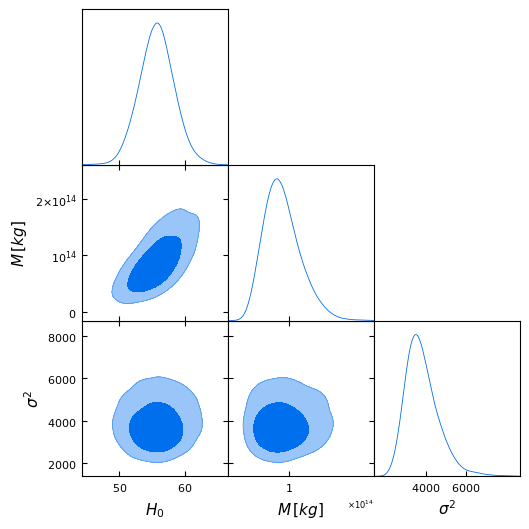

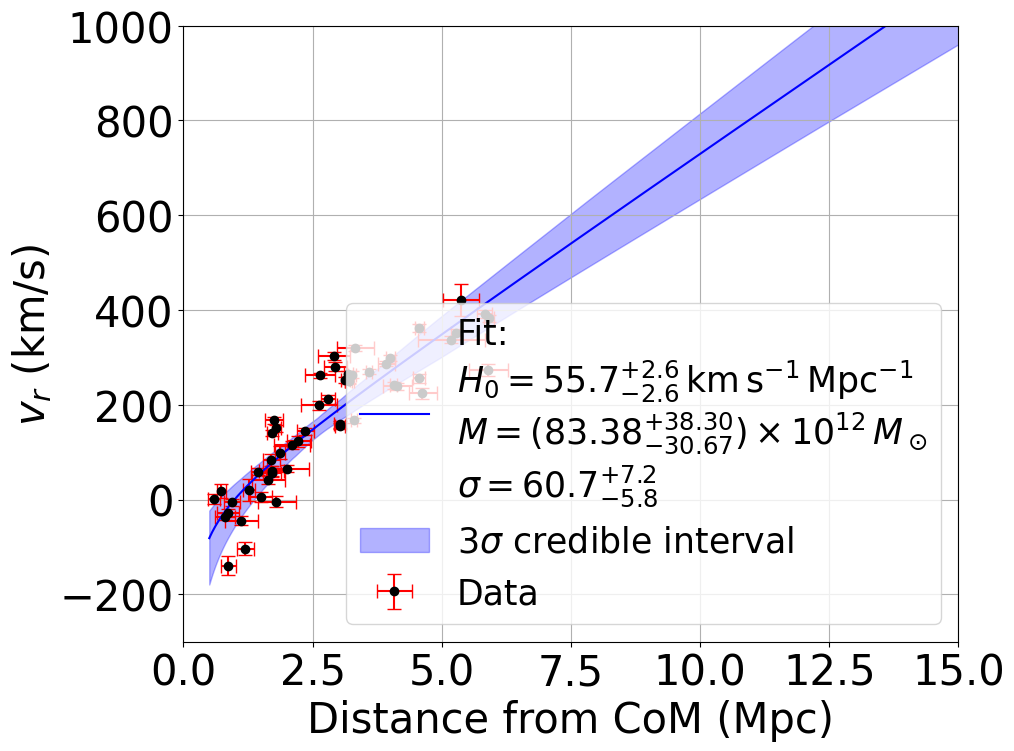

In [31]:
H0_min, M_min,sigma_min, samples_min = analyze_velocity_model(df=df, mask= mask,row_name= row_name,velocity='minor_infall_velocity',velocity_model=velocity_model_1, xmin=0.5, xmax=6)

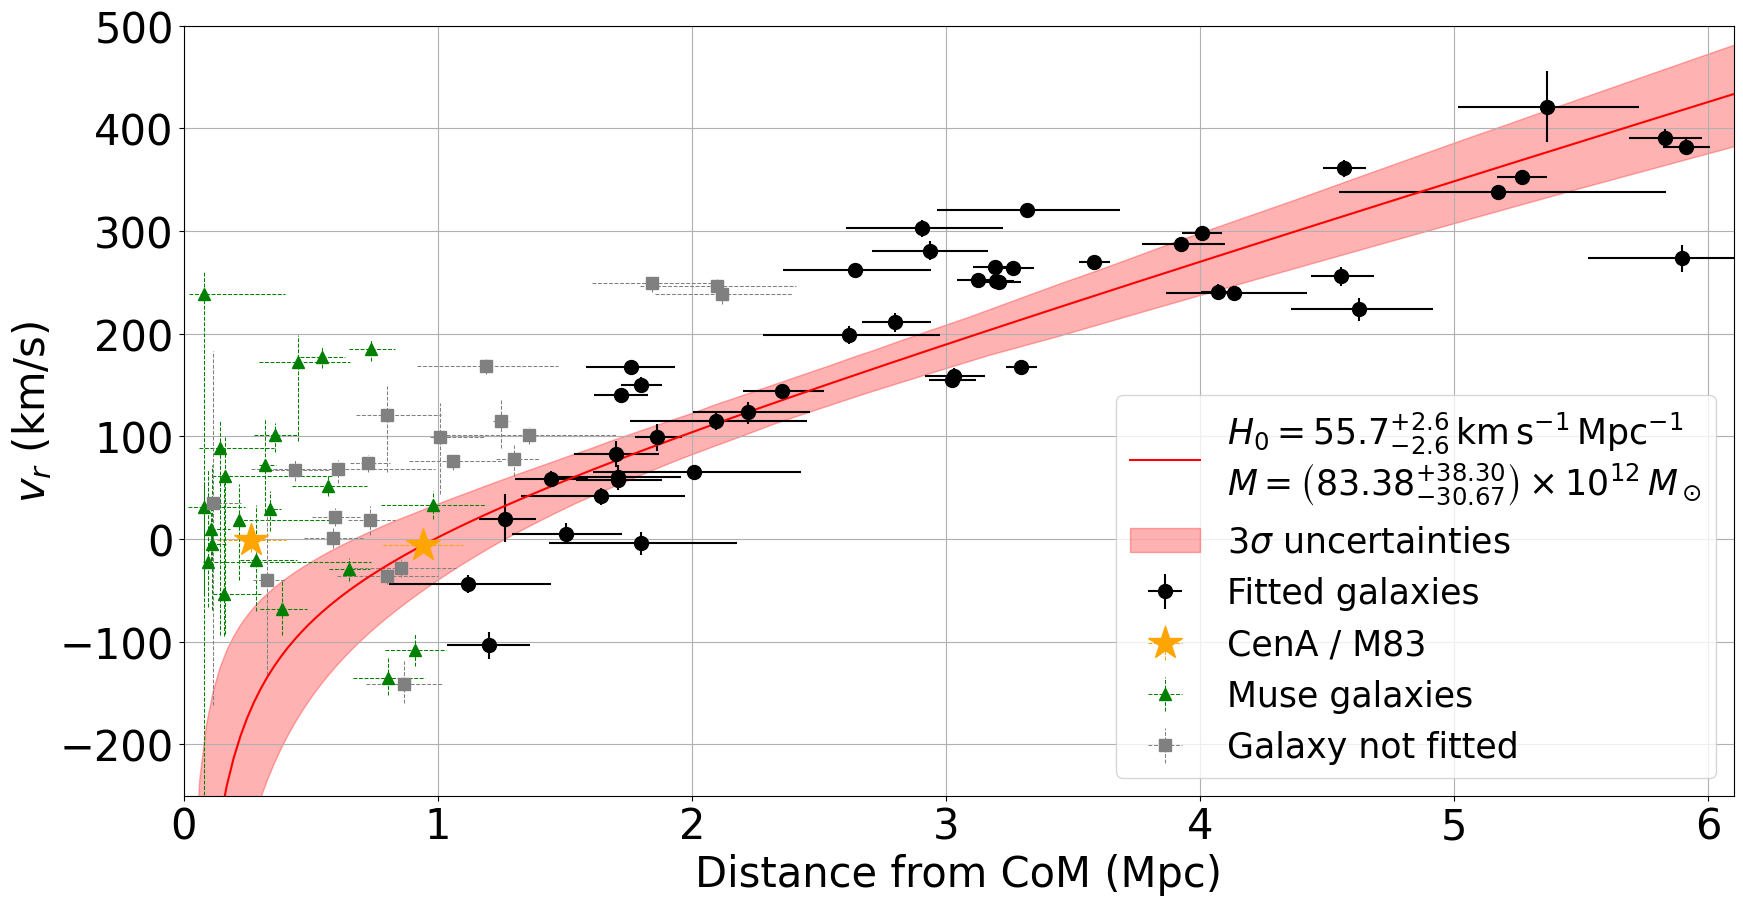

In [32]:
plot_model_fitted(velocity='minor_infall_velocity',velocity_model=velocity_model_1,mask=mask,H0=H0_min,M=M_min,sigma=sigma_min,samples=samples_min)

# Major infall

Taille avant filtrage avec le masque (df_filtered): (98, 28)
Taille après filtrage avec le masque (df_filtered): (97, 28)
Taille après filtrage 'LEDA' (is_LEDA): (75, 28)
Taille après conversion et dropna (df_clean): (75, 6)


100%|██████████| 5000/5000 [00:15<00:00, 320.76it/s]


Removed no burn in


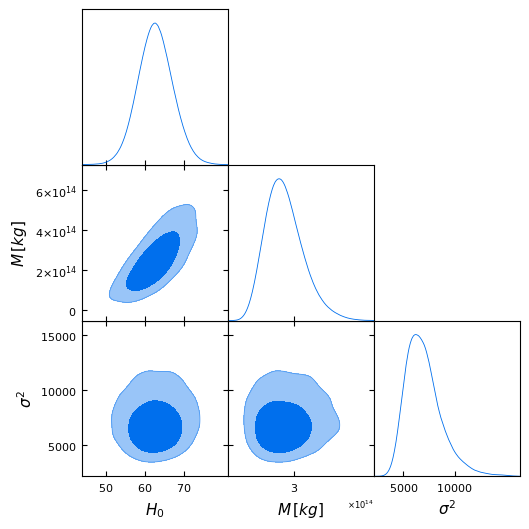

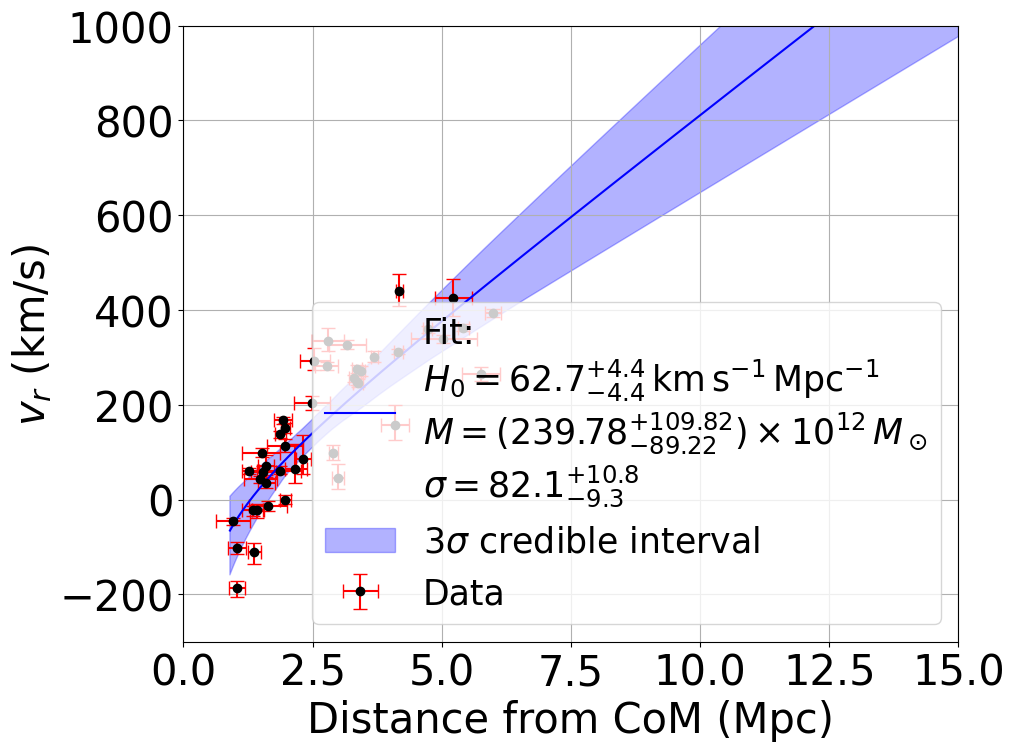

In [ ]:
H0_maj,  M_maj, sigma_maj, samples_maj  = analyze_velocity_model(df=df, mask= mask,row_name= row_name,velocity='major_infall_velocity',velocity_model=velocity_model_1, xmin=0.9, xmax=6)

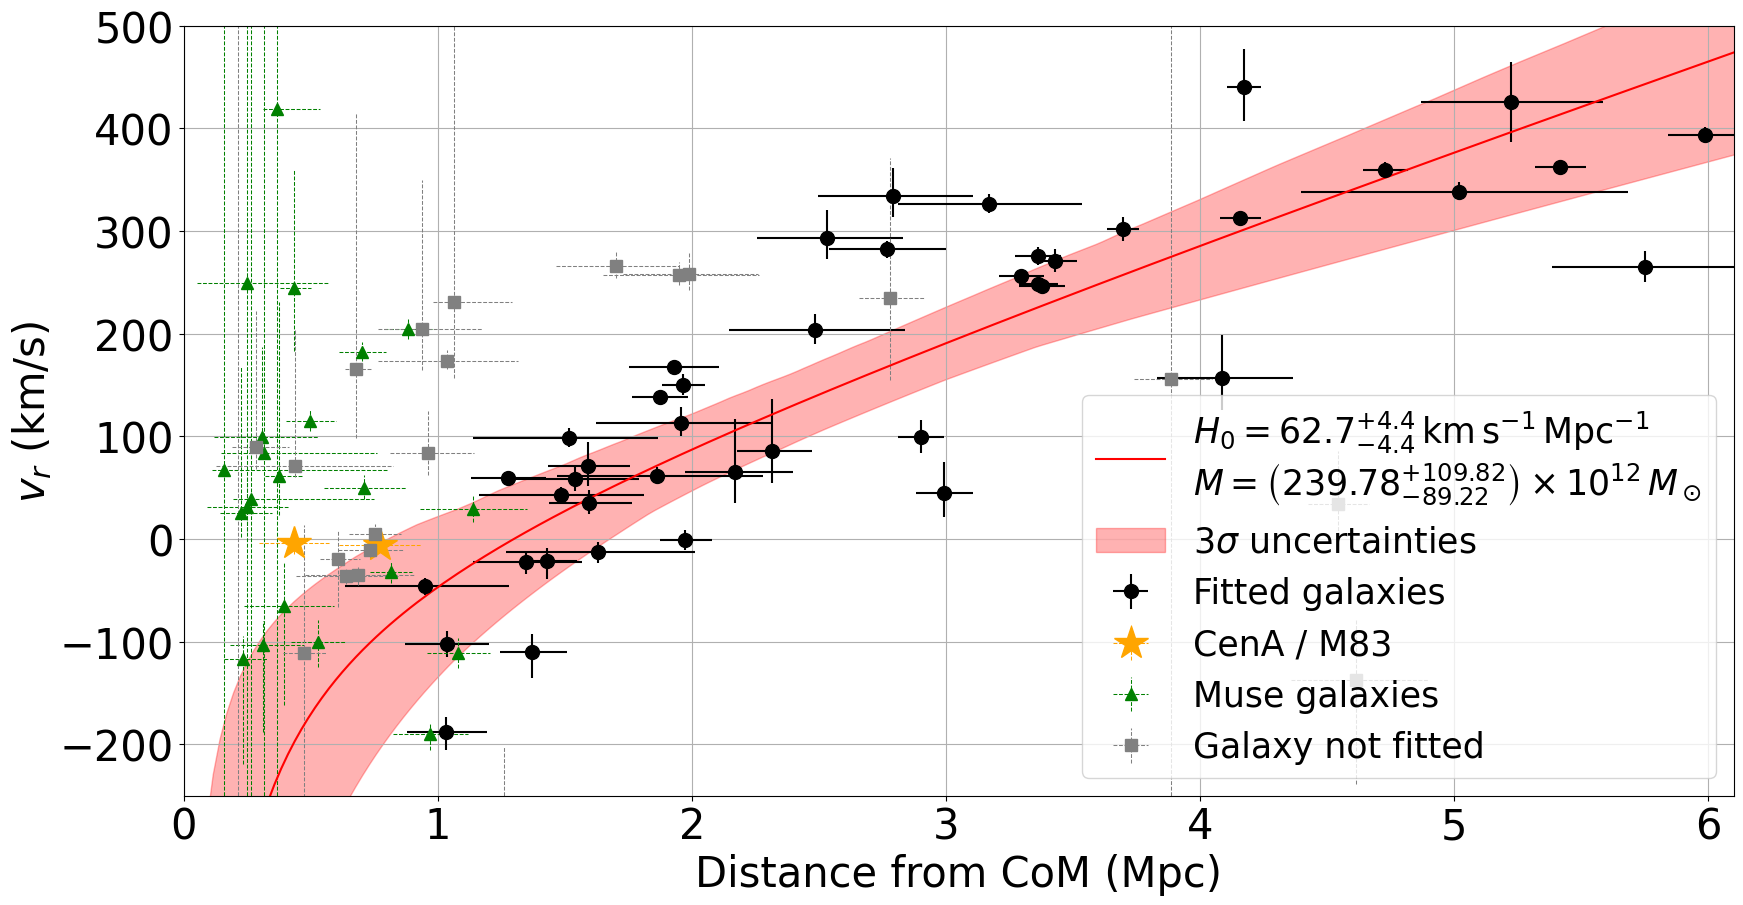

In [ ]:
plot_model_fitted(velocity='major_infall_velocity',velocity_model=velocity_model_1,mask=mask,H0=H0_maj,M=M_maj,sigma=sigma_maj,samples=samples_maj)

Removed no burn in
Removed no burn in
['H0', 'sqrt_sigma', 'M']


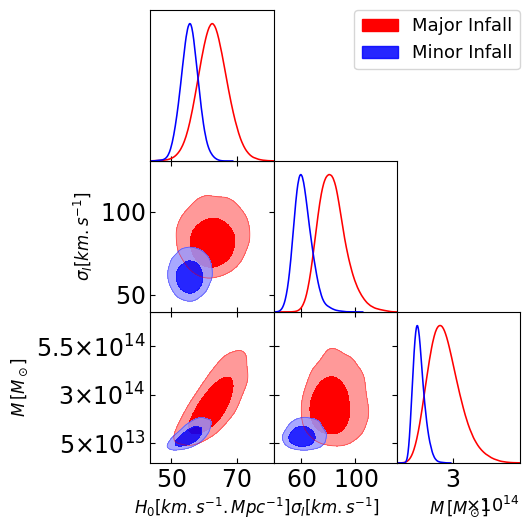

=== Résultats Minor Infall ===


NameError: name 'H0_sigma_min' is not defined

In [33]:
samples_min_display = np.column_stack((samples_min[:, 0],         # H0
                                              # M
                                       np.sqrt(samples_min[:, 2]), # sqrt_sigma
                                       samples_min[:, 1]
                                      ))

samples_maj_display = np.column_stack((samples_maj[:, 0], 
                                        
                                       np.sqrt(samples_maj[:, 2]),
                                       samples_maj[:, 1]
                                      ))

names = ['H0','sqrt_sigma', 'M', ]
labels = [r'H_0 [km.s^{-1}.Mpc^{-1}]', r'\sigma_I [km.s^{-1}]',r'M \,[M_\odot]', ]

# Créer les objets MCSamples pour les deux analyses
gdsamples_min = MCSamples(samples=samples_min_display, names=names, labels=labels)
gdsamples_maj = MCSamples(samples=samples_maj_display, names=names, labels=labels)
print([p.name for p in gdsamples_maj.getParamNames().names])

settings = plots.GetDistPlotSettings()
settings.axes_fontsize = 20      # Size of axis labels (e.g., 'H_0', 'M')
settings.lab_fontsize = 15       # Size of axis titles
settings.legend_fontsize = 16     # Legend font size
settings.title_limit_fontsize = 16
settings.linewidth = 2            # Thickness of the contour lines

# Create plotter with custom settings
g = plots.get_subplot_plotter(settings=settings)

g.triangle_plot([gdsamples_maj, gdsamples_min],  # ordre : rouge derrière, bleu devant
                filled=True, 
                legend_labels=['Major Infall', 'Minor Infall'],
                colors=['red', 'blue'],
                line_args=[{'color': 'red'}, {'color': 'blue'}],
                filled_args=[{'alpha': 0.3}, {'alpha': 0.6}]  # rouge plus transparent
)
# g.export('../../../../plot/triangle_plot.png', dpi=300)
plt.show()

# Optionnel : afficher les résultats numériques
print("=== Résultats Minor Infall ===")
print(f"H0 = {H0_min[0]:.2f} ± {H0_sigma_min:.2f}")
print(f"M = ({M_min/1e12:.2f} ± {M_sigma_min/1e12:.2f}) × 10^12 M_☉")

print("\n=== Résultats Major Infall ===")
print(f"H0 = {H0_maj:.2f} ± {H0_sigma_maj:.2f}")
print(f"M = ({M_maj/1e12:.2f} ± {M_sigma_maj/1e12:.2f}) × 10^12 M_☉")
plt.show()


In [ ]:
plot_fit_max_dist(df=df,mask=mask,row_name=row_name,velocity='minor_infall_velocity',velocity_model=velocity_model_1,xmin=1,xminmax=5,xmaxmax=9,Nb_point=10)

 69%|██████▉   | 3462/5000 [00:11<00:04, 311.50it/s]


KeyboardInterrupt: 

  0%|          | 0/5000 [00:00<?, ?it/s]

100%|██████████| 5000/5000 [00:15<00:00, 331.58it/s]


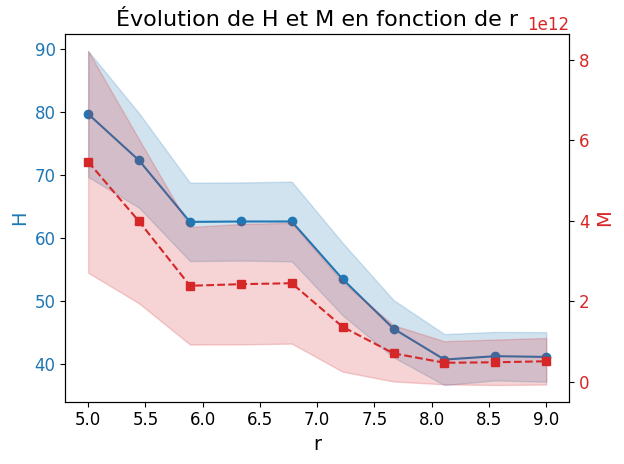

In [ ]:
plot_fit_max_dist(df=df,mask=mask,row_name=row_name,velocity='major_infall_velocity',velocity_model=velocity_model_1,xmin=1,xminmax=5,xmaxmax=9,Nb_point=10)

  0%|          | 0/5000 [00:00<?, ?it/s]

100%|██████████| 5000/5000 [00:13<00:00, 372.29it/s]


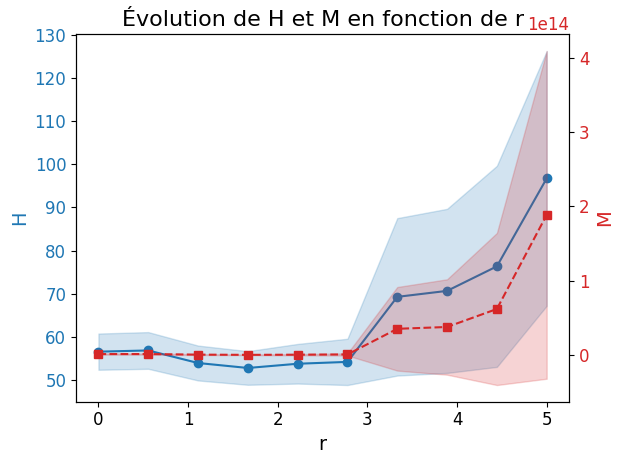

In [ ]:
plot_fit_min_dist(df=df,mask=mask,row_name=row_name,velocity='minor_infall_velocity',velocity_model=velocity_model_1,xmax=7,xminmin=0,xmaxmin=5,Nb_point=10)

  0%|          | 0/5000 [00:00<?, ?it/s]

100%|██████████| 5000/5000 [00:16<00:00, 298.79it/s]


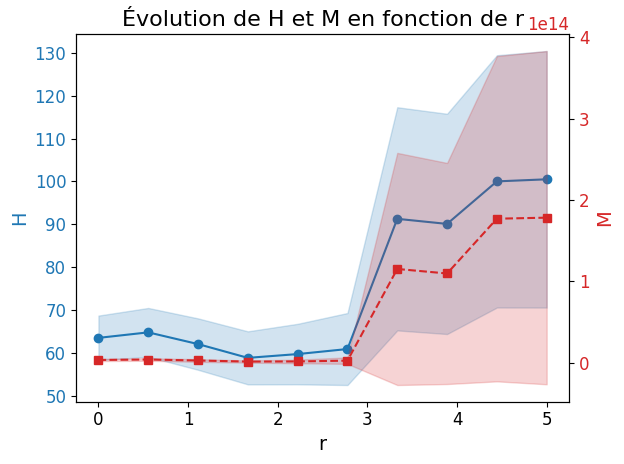

In [ ]:
plot_fit_min_dist(df=df,mask=mask,row_name=row_name,velocity='major_infall_velocity',velocity_model=velocity_model_1,xmax=7,xminmin=0,xmaxmin=5,Nb_point=10)